# ***线性神经网络***

## 1.1线性回归

### 1.1.1线性回归的基本元素

In [26]:
import math
import time
import numpy as np
import torch
import matplotlib.pyplot as plt

In [27]:
n = 10000
a = torch.ones([n])
b = torch.ones([n])

由于需要频繁进行运行时间的基准测试在这里定义一个计时器

In [28]:
class Timer:
    """记录多次运行时间"""
    def __init__(self):
        self.times = []
        self.start()
    def start(self):
        """启动计时器"""
        self.tik = time.time()
    def stop(self):
        """停止计时器并将时间记录在列表中"""
        self.times.append(time.time() - self.tik)
        return self.times[-1]
    def avg(self):
        """返回平均时间"""
        return sum(self.times) / len(self.times)
    def sum(self):
        """返回时间总和"""
        return sum(self.times)
    def cumsum(self):
        """返回累计时间"""
        return np.array(self.times).cumsum().tolist()

现在我们来进行基准测试

In [29]:
c = torch.zeros(n)
timer = Timer()
for i in range(n):
    c[i] = a[i] + b[i]
f'{timer.stop():.5f} sec'

'0.04655 sec'

In [30]:
timer.start()
d = a + b
f'{timer.stop():.5f} sec'

'0.00010 sec'

结果很明显，矢量化代码会带来数量级的加速，并且将更多的数学运算放到库中，减少了可能出现的编写计算错误

### 1.1.2正态分布与平方损失

In [31]:
#定义一个正态分布函数
def normal(x , mu , sigma):
    p = 1 / math.sqrt(2 * math.pi * sigma ** 2)
    return p * np.exp(-0.5 / sigma ** 2 * (x - mu) ** 2)

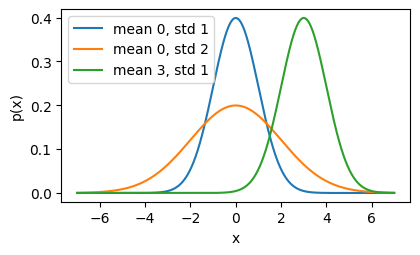

In [32]:
x = np.arange(-7, 7, 0.01)
params = [(0, 1), (0, 2), (3, 1)]
def normal(x, mu, sigma):
    return (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mu) / sigma) ** 2)

plt.figure(figsize=(4.5, 2.5))          # figsize
# 每次画一条曲线，并设置标签
for (mu, sigma), label in zip(params, [f'mean {mu}, std {sigma}' for mu, sigma in params]):
    y = normal(x, mu, sigma)
    plt.plot(x, y, label=label)
plt.xlabel('x')                         # xlabel
plt.ylabel('p(x)')                      # ylabel
plt.legend()                            # legend 自动提取每条线的 label
plt.show()

改变均值会产生沿x轴的偏移，增加方差将会分散分布、降低其峰值

## 1.2线性回归的实现

### 1.2.1生成数据集

features: tensor([ 0.0496, -1.6527]) 
label: tensor([9.9144])


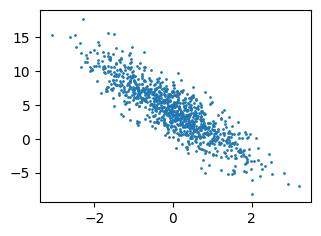

In [33]:
import random
import torch
import matplotlib.pyplot as plt
#构建一个人造数据集
def synthetic_data(w , b , num_examples):
    """生成y = wX + b + 噪声"""
    X = torch.normal(0 , 1 , (num_examples , len(w)))  #X均值为0,方差为1的随机数
    y = torch.matmul(X , w) + b
    y += torch.normal(0 , 0.01 , y.shape)  #添加一个和y形状一样的方差为0.01的噪声
    return X , y.reshape((-1 , 1))  #-1表示自动推断该维度大小
true_w = torch.tensor([2 , -3.4])
true_b = 4.2
features , labels = synthetic_data(true_w , true_b , 1000)
print('features:', features[0],'\nlabel:', labels[0])
plt.figure(figsize=(3.5 , 2.5))
plt.scatter(features[: , 1].detach().numpy(), labels.detach().numpy(), s=1)


w表示权重向量（斜率），b表示偏置，num_examples表示要生成的样本数量，X是一个有num_examples行、len(w)列的矩阵。每一行代表一个样本，每一列代表一个特征，所有值均独立地从N(0,1)N(0,1)中抽取。  返回的features是特征值x1,x2，label对应的是基于特征值x1,x2计算出的y

### 线性回归例子：特征矩阵维度与矩阵乘法

假设真实模型为：
$$ \mathbf{w} = \begin{bmatrix} 2 \\ -1 \end{bmatrix}, \quad b = 0.5 $$
即权重向量长度为 2，每个样本需要 2 个特征：$x_1$ 和 $x_2$。

生成 3 个样本的特征矩阵 $\mathbf{X}$（形状 $3 \times 2$）：
$$ \mathbf{X} = \begin{bmatrix} 3 & 1 \\ 0 & 2 \\ 5 & -1 \end{bmatrix} $$

- 第 1 行：样本 1 $(x_1=3,\ x_2=1)$  
- 第 2 行：样本 2 $(x_1=0,\ x_2=2)$  
- 第 3 行：样本 3 $(x_1=5,\ x_2=-1)$  

---

### 逐样本计算预测值 $y = w_1 x_1 + w_2 x_2 + b$

- **样本 1**：$y_1 = 2 \times 3 + (-1) \times 1 + 0.5 = 6 - 1 + 0.5 = 5.5$
- **样本 2**：$y_2 = 2 \times 0 + (-1) \times 2 + 0.5 = 0 - 2 + 0.5 = -1.5$
- **样本 3**：$y_3 = 2 \times 5 + (-1) \times (-1) + 0.5 = 10 + 1 + 0.5 = 11.5$

---

### 用矩阵乘法一次性计算

$$ \mathbf{X}\mathbf{w} = \begin{bmatrix} 3 & 1 \\ 0 & 2 \\ 5 & -1 \end{bmatrix} \begin{bmatrix} 2 \\ -1 \end{bmatrix} = \begin{bmatrix} 3\cdot 2 + 1\cdot(-1) \\ 0\cdot 2 + 2\cdot(-1) \\ 5\cdot 2 + (-1)\cdot(-1) \end{bmatrix} = \begin{bmatrix} 5 \\ -2 \\ 11 \end{bmatrix} $$

加上偏置 $b=0.5$（广播到每一行）：

$$ \mathbf{\hat{y}} = \begin{bmatrix} 5 \\ -2 \\ 11 \end{bmatrix} + 0.5 = \begin{bmatrix} 5.5 \\ -1.5 \\ 11.5 \end{bmatrix} $$

结果与逐样本计算一致。

---

**结论**：特征矩阵 $\mathbf{X}$ 的列数必须等于权重向量 $\mathbf{w}$ 的长度，因为每一列对应一个特征，点积要求特征与权重一一对应。矩阵乘法则将多个样本的线性组合一次性完成。

### 1.2.2读取数据集

In [34]:
def data_iter(batch_size, features, labels):  #输入每个小批量包含的样本数，特征，标签
    """读取数据集"""
    num_examples = len(features)
    indices = list(range(num_examples))  #生成一个列表
    random.shuffle(indices)  #将列表中的元素打乱顺序
    for i in range(0, num_examples, batch_size):
        batch_indices = torch.tensor(
            indices[i: min(i + batch_size, num_examples)])
        yield features[batch_indices], labels[batch_indices]

In [35]:
batch_size = 10
for X , y in data_iter(batch_size , features , labels):
    print(X , '\n' , y)
    break

tensor([[ 0.2484, -0.6054],
        [-0.6250, -0.1510],
        [-0.1931,  0.6279],
        [ 0.3422, -0.1909],
        [-1.6836,  2.0171],
        [ 0.6626, -0.1374],
        [ 0.4675, -1.9093],
        [-0.5074, -1.3534],
        [-0.4557,  0.3986],
        [-0.0658, -0.8976]]) 
 tensor([[ 6.7537],
        [ 3.4608],
        [ 1.6826],
        [ 5.5272],
        [-6.0476],
        [ 5.9972],
        [11.6154],
        [ 7.7798],
        [ 1.9244],
        [ 7.1096]])


### 1.2.3 初始化模型参数

In [36]:
w = torch.normal(0, 0.01, size=(2,1), requires_grad=True)  #requires_grad=True表示计算梯度
b = torch.zeros(1, requires_grad=True)  #偏差的初始值给0,并且打开梯度计算进行更新

### 1.2.4定义模型

In [37]:
def linreg(X, w, b):
    """线性回归模型"""
    return torch.matmul(X, w) + b   #返回w*X+b的线性表达式

### 1.2.5定义损失函数

In [38]:
def squared_loss(y_hat, y):  #y_hat为预测值，y为真实值
    """均方误差"""
    return(y_hat - y.reshape(y_hat.shape)) ** 2 / 2  #返回均方误差表达式

### 1.2.6定义优化算法

In [39]:
def sgd(params, lr, batch_size): 
    """小批量随机梯度下降"""
    with torch.no_grad():  #关闭梯度记录
        for param in params:
            param -= lr * param.grad / batch_size  #所有样本的梯度综合除以样本数，得到每个样本的平均梯度再乘学习率
            param.grad.zero_()  #将w.grad里面的梯度值清零

最终，所有参数向损失减小的方向微微移动了一点，并且梯度的“旧账”被抹去，为下一批数据的梯度计算准备好干净的累加器。整个过程就是标准的参数更新 + 清空梯度两步走，简单而关键。

#### 直观类比
想象你在爬山，每走一步都会用 GPS 记录轨迹（这就是计算图）。
- **梯度**是指南针，告诉你“往左走 0.5 米能下山最快”。
- **更新参数**就是你实际迈出左脚，移动了 0.5 米。
- 这个“迈步”动作本身，你并不需要它被记录成新的轨迹路线（否则下次看地图时会发现一个多余的、不相关的“走路步长”被当作了地形的一部分）。`no_grad()` 就是让你迈步时暂时关掉 GPS，走完之后再重新打开。

#### 一句话总结
梯度**指导**怎么更新参数，但**更新参数这个操作本身不属于模型的“计算”**，必须用 `no_grad()` 排除在计算图外，否则自动微分系统会把它当作用户定义的运算，导致逻辑错误或计算混乱。

### 1.2.7训练

In [40]:
#定义训练超参数和核心组建
lr = 0.03  #定义学习率为0.03
num_epochs = 3  #定义训练的轮次
net = linreg  #选择网络模型，这里直接赋值为之前定义的linreg函数
loss = squared_loss  #定义损失函数，这里直接赋值为之前定义的squared_loss函数

In [41]:
for epoch in range(num_epochs):  #控制训练的轮数
    for X, y in data_iter(batch_size, features, labels):  #每次返回一个小样本的特征x和标签y
        l = loss(net(X, w, b), y)
        # X和y的小批量损失
        # 因为l形状是(batch_size,1)，而不是一个标量。l中的所有元素被加到一起，
        # 并以此计算关于[w,b]的梯度
        l.sum().backward()
        #因为l不是标量，不能直接调用.backward()。需要先用.sum()将所有样本的损失加起来，变成一个标量。
        #在标量上调用.backward()会自动计算w和b的梯度，并累加到w.grad和b.grad中。
        #由于我们对整个小批量的损失求和，所以w.grad和b.grad是这小批量所有样本梯度的总和。
        sgd([w, b], lr, batch_size)
        #调用我们之前定义的sgd函数，用w.gard/batch_size得到平均梯度
        #沿着负平均梯度方向更新w和b
        #清空w.grad和b.grad，为下一个小批量做准备
    with torch.no_grad():  #评估时不需要计算梯度，关闭自动求导以节省内存和加速。
        train_l = loss(net(features, w, b), labels) 
        #net(features, w, b)：用整个数据集（不是小批量）和当前的参数做前向计算。
        #loss(...) 得到每个样本的损失，形状 (1000, 1)。
        print(f'epoch {epoch + 1}, loss {float(train_l.mean()):f}')
        #train_l.mean()：计算所有样本损失的平均值，得到一个标量，反映当前模型在整个数据集上的表现。
        #print(...)：输出当前 epoch 的平均损失，让我们看到训练是否在收敛。

epoch 1, loss 0.032577
epoch 2, loss 0.000120
epoch 3, loss 0.000050


In [42]:
print(f'w的估计误差: {true_w - w.reshape(true_w.shape)}')
print(f'b的估计误差: {true_b - b}')

w的估计误差: tensor([-0.0007, -0.0003], grad_fn=<SubBackward0>)
b的估计误差: tensor([0.0004], grad_fn=<RsubBackward1>)


因为我们使用的是自己合成的数据集，所以我们知道真正的参数是什么。因此，我们可以通过比较真实参数
和通过训练学到的参数来评估训练的成功程度。事实上，真实参数和通过训练学到的参数确实非常接近。

# 训练循环详细流程解析

## 代码全貌

```python
for epoch in range(num_epochs):                # 外层循环：遍历每个 epoch
    for X, y in data_iter(batch_size, features, labels):  # 内层循环：按小批量取数据
        l = loss(net(X, w, b), y)              # ① 前向计算 + 损失
        l.sum().backward()                     # ② 反向传播，计算梯度
        sgd([w, b], lr, batch_size)            # ③ 更新参数并清空梯度
    with torch.no_grad():                       # ④ 评估模式（不记录梯度）
        train_l = loss(net(features, w, b), labels)
        print(f'epoch {epoch + 1}, loss {float(train_l.mean()):f}')
```

---

## 前提假设

- `w`, `b` 已初始化为随机值（例如 `w = torch.normal(0, 0.01, size=(2,), requires_grad=True)`）。
- `batch_size = 10`，总样本数 `num_examples = 1000`，特征数 `len(w) = 2`。
- 每个 epoch 有 `1000 / 10 = 100` 个小批量。
- `net` 就是 `linreg`：`def linreg(X, w, b): return X @ w + b`。
- `loss` 是 `squared_loss`：返回形状为 `(batch_size, 1)` 的每个样本损失。
- `sgd` 会用平均梯度更新参数并清空梯度。

---

## 流程逐步解析

### 第一步：`for epoch in range(num_epochs):`（外层循环）

- **执行次数**：`num_epochs = 3`，所以会运行 3 遍整个数据集。
- **目的**：每运行一遍，模型参数会得到一次完整的优化，通常损失会逐步下降。

---

### 第二步：`for X, y in data_iter(batch_size, features, labels):`（内层循环）

- `data_iter` 在每次被调用时（即每个 epoch 开始时）会重新打乱所有样本索引。
- 然后按 `batch_size = 10` 切分，每次 `yield` 一个 `(X_batch, y_batch)`。
- 一个 epoch 内循环 100 次，每次拿出 10 个样本。

---

### 第三步：`l = loss(net(X, w, b), y)`（前向 + 损失）

- **前向计算**：  
  `y_hat = X @ w + b`，形状 `(10, 1)`。
- **损失计算**：  
  `l = (y_hat - y.reshape(y_hat.shape)) ** 2 / 2`，形状 `(10, 1)`。  
  每个元素是单个样本的均方误差的一半。

此时 `l` 不是标量，而是一个列向量。

---

### 第四步：`l.sum().backward()`（求和并反向传播）

- `l.sum()` 将所有样本的损失加成一个标量，即这个小批量的总损失。
- 在标量上调用 `.backward()`，PyTorch 自动沿着计算图反向传播，计算出 `w.grad` 和 `b.grad`。
- **重要**：因为梯度的定义是对 **标量** 求导，所以必须先将向量转化为标量。
- 梯度会 **累加** 到已有 `w.grad` 和 `b.grad` 上（首次累加时它们初始为 `None`，被自动初始化为零张量）。

当前这个小批量的 **梯度和** 被存在 `w.grad` 和 `b.grad` 中。

---

### 第五步：`sgd([w, b], lr, batch_size)`（参数更新 + 梯度清零）

- 函数内部逻辑（回顾）：
  1. 进入 `torch.no_grad()`，防止更新操作被记录。
  2. 对每个参数：
     - `param -= lr * (param.grad / batch_size)` → 用平均梯度更新。
     - `param.grad.zero_()` → 清空梯度，为下一个小批量做准备。
- 这一步后，`w` 和 `b` 的值被略微修改，朝损失减小的方向移动，并且它们的梯度已被清零。

---

### 第六步：回到内层循环顶部，取下一批数据

重复步骤三到五，直到 100 个小批量全部处理完毕，完成一个 epoch。

---

### 第七步：`with torch.no_grad():`（关闭梯度计算）进行 epoch 评估

- 这一个 epoch 的所有小批量训练结束后，用 **整个训练集** 计算一次损失，看看模型整体表现。
- `train_l = loss(net(features, w, b), labels)`：
  - `features` 是全部 1000 个样本的特征矩阵，`labels` 是全部标签列向量。
  - 得到形状 `(1000, 1)` 的每个样本损失。
- `train_l.mean()`：计算整个训练集的平均损失（标量）。
- 打印当前 epoch 编号和平均损失。
- `torch.no_grad()` 确保这个评估过程不产生任何梯度，避免干扰。

---

### 第八步：进入下一个 epoch

外层循环递增 `epoch`，回到第一步，重新打乱数据，再次进行 100 个小批量的训练，然后再次评估……

---

## 数据流与维度变化

| 步骤 | 操作 | 输入/输出形状 | 说明 |
|------|------|----------------|------|
| 取小批量 | `data_iter` 产出 `X, y` | `X`: `(10, 2)`<br>`y`: `(10, 1)` | 10 个样本，每样本 2 特征 |
| 预测 | `net(X, w, b)` | `y_hat`: `(10, 1)` | 矩阵乘法与加法 |
| 损失 | `loss(y_hat, y)` | `l`: `(10, 1)` | 各样本的 ½ 平方误差 |
| 求和 | `l.sum()` | 标量 | 小批量总损失 |
| 反向 | `.backward()` | `w.grad`: `(2,)`，`b.grad`: 标量 | 梯度累加 |
| 更新 | `sgd([w,b], ...)` | `w` 更新，梯度清零 | 参数朝更优方向移动 |
| 评估 | `loss(net(features,...), labels)` | `train_l`: `(1000, 1)` | 计算全量损失 |
| 平均 | `train_l.mean()` | 标量 | 评估指标，用于打印 |

---

## 关键细节答疑

### 为什么要 `l.sum().backward()` 而不是 `l.mean().backward()`？
- 两者本质等价，因为 `mean()` 就是 `sum() / n`，梯度也会缩放 `1/n`。
- 这里采用 `sum()`，并在 `sgd` 中手动除以 `batch_size`，这样可以在更新时灵活控制批量大小对学习率的影响，逻辑更清晰。

### 为什么在 `sgd` 里清空梯度而不是在循环末尾统一清零？
- 因为 `sgd` 是“更新完一个参数立即清零它的梯度”，避免下一个小批量反向传播时发生错误累加。
- 如果等到所有参数更新完再清，可能存在多个参数间梯度干扰的风险，而且不符合常规写法。

### 评估时为什么还调用 `loss` 函数？
- 直接复用损失计算逻辑，保持衡量标准一致。
- 输出的平均损失可以直观看到模型的学习进展（应随 epoch 增加而下降）。

---

## 总结

整个训练循环就是一个 **“取数据 → 算损失 → 求梯度 → 更新参数 → 再取下一批”** 的反复过程，每个 epoch 完成后观察整体损失。这个骨架几乎适用于所有 PyTorch 监督学习任务。